# Reproducible Notebook Environment for Shrubwise Data Challenge Final Submission

## Setup
### Step 1. Create new conda environment with Python installed
`conda create --name reproduce_env python`  
Enter `y` when asked to install packages  
  
In our setup Python 3.14.4 is installed by default. Try this version if you have issues with another version of Python.  

**Note**  
requirements.txt takes 5-10 minutes to download as we utilize pytorch and torchvision libraries.

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import subprocess
import os
from pathlib import Path

# Check if we're already in the shrub repo (look for Final and Sprint 3 directories)
current_dir = Path.cwd()
if not ((current_dir / "Final").exists() and (current_dir / "Sprint 3").exists()):
    # We're in the parent directory, need to navigate to or clone shrub/
    shrub_dir = current_dir / "shrub"
    if not shrub_dir.exists():
        print("Cloning shrub repository (takes 2-3 minutes)...")
        print("Starting Clone...")
        try:
            subprocess.run(
                ["git", "clone", "https://github.com/ICharmU/shrub.git"], 
                check=True,          # Forces Python to raise an error if the command fails
                capture_output=True, # Captures stdout and stderr
                text=True            # Returns strings instead of bytes
            )
        except subprocess.CalledProcessError as e:
            print(f"Git clone failed. Ensure Git is installed and in your PATH.")
            print(f"Error details: {e.stderr}")
            raise # Stops execution so you don't hit the FileNotFoundError below
    
    # Change to shrub directory - this is critical for Final.paths to work
    print("Clone successful!")
    os.chdir(shrub_dir)
    print(f"✓ Changed working directory to: {os.getcwd()}")
else:
    print(f"✓ Already in shrub repository: {os.getcwd()}")

# Verify the expected directories exist
assert (Path.cwd() / "Final").exists(), "Final directory not found!"
assert (Path.cwd() / "Sprint 3").exists(), "Sprint 3 directory not found!"

print("✓ Repository structure verified")
print("✓ All imports will now resolve correctly")

Clone successful!
✓ Changed working directory to: c:\Users\seani\OneDrive\Desktop\shrubwise_data_challenge_submission\shrub
✓ Repository structure verified
✓ All imports will now resolve correctly


# Runner

In [3]:
# Core imports and setup
import json
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from dataclasses import asdict
from pprint import pprint

# Import only what's available in this repo version
from Final.config import default_config
from Final.paths import FINAL_ROOT
from Final.shared_utils import setup_logging, get_logger

# Note: Pipeline-specific config classes (ModelingPipelineConfig, etc.)
# are not available in this submission repo. We'll use default configs instead.

# Initialize config and logging
cfg = default_config()
logger = setup_logging(
    name="submission_runner",
    log_dir=cfg.output.logs_root,
    log_filename="submission_runner.log",
    force=True,
)

# Set output directories
RUNNER_OUTPUT_ROOT = cfg.output.root / "submission_runner"
RUNNER_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("✓ Imports and logging configured")
print(f"  Project root: {cfg.data.project_root}")
print(f"  Output root: {cfg.output.root}")
print(f"  Available sites: {cfg.sites}")

✓ Imports and logging configured
  Project root: C:\Users\seani\OneDrive\Desktop\shrubwise_data_challenge_submission\shrub
  Output root: C:\Users\seani\OneDrive\Desktop\shrubwise_data_challenge_submission\shrub\Final\artifacts
  Available sites: ['calaveras-big-trees', 'dl-bliss', 'independence-lake', 'pacific-union-college', 'sedgwick', 'shaver-lake']


In [4]:
# Configuration: Choose your site
# Available sites: calaveras-big-trees, dl-bliss, independence-lake, pacific-union-college, sedgwick, shaver-lake

TEST_SITE = "calaveras-big-trees"  # Change this to run on a different site

# Update config to test on single site
cfg.site.sites = [TEST_SITE]

# Note: Pipeline-specific configurations (model family, feature profile, etc.)
# should be set using the pipeline.py modules directly if needed.
# This submission repo provides a simplified interface.

print(f"✓ Configuration ready")
print(f"  Test site: {TEST_SITE}")
print(f"  Output directory: {cfg.output.root}")

✓ Configuration ready
  Test site: calaveras-big-trees
  Output directory: C:\Users\seani\OneDrive\Desktop\shrubwise_data_challenge_submission\shrub\Final\artifacts


In [13]:
# INSERT MODEL HERE

In [5]:
# [PLACEHOLDER] Generate sample data
# TODO: Replace with processed data from Google Drive
# Expected input: label rasters and feature matrices for {test_site}

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from Final.modeling.pipeline import ModelingPipeline

test_site = TEST_SITE

print(f"Generating sample data for {test_site.upper()}...")
print(f"  (Placeholder - waiting for processed Google Drive data)")

# Generate synthetic labels and predictions
np.random.seed(42)
n_pixels = 50000

# Synthetic labels (30% positive shrubs, 70% background)
labels = np.random.binomial(n=1, p=0.3, size=n_pixels)

# Synthetic predictions (well-calibrated, models better on shrubs)
predictions = np.zeros(n_pixels)
predictions[labels == 1] = np.random.beta(8, 2, sum(labels == 1))
predictions[labels == 0] = np.random.beta(2, 8, sum(labels == 0))
predictions = np.clip(predictions, 0, 1)

binary_preds = (predictions > 0.5).astype(int)

print(f"✓ Sample data created")
print(f"  Labels: {n_pixels} pixels ({np.sum(labels)} shrubs, {n_pixels - np.sum(labels)} background)")
print(f"  Predictions: range [{predictions.min():.3f}, {predictions.max():.3f}]")

Generating sample data for CALAVERAS-BIG-TREES...
  (Placeholder - waiting for processed Google Drive data)
✓ Sample data created
  Labels: 50000 pixels (14845 shrubs, 35155 background)
  Predictions: range [0.001, 0.999]


In [6]:
# Calculate metrics using Final.modeling.pipeline functions
# Import the built-in metric functions used by the modeling pipeline
from Final.modeling.pipeline import ModelingPipeline

# Dice score function from Final.modeling.pipeline._dice_score
def _dice_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Dice coefficient - from Final.modeling.pipeline"""
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)
    denom = float(y_true.sum() + y_pred.sum())
    if denom <= 0:
        return 1.0
    return float(2.0 * (y_true * y_pred).sum() / denom)

def get_metrics(predictions_probs, labels, threshold=0.5):
    """Calculate metrics using Final.modeling.pipeline functions"""
    binary_preds = (predictions_probs >= threshold).astype(int)
    
    dice = _dice_score(labels, binary_preds)
    accuracy = accuracy_score(labels, binary_preds)
    precision = precision_score(labels, binary_preds, zero_division=0)
    recall = recall_score(labels, binary_preds, zero_division=0)
    f1 = f1_score(labels, binary_preds, zero_division=0)
    
    tp = np.sum((binary_preds == 1) & (labels == 1))
    tn = np.sum((binary_preds == 0) & (labels == 0))
    fp = np.sum((binary_preds == 1) & (labels == 0))
    fn = np.sum((binary_preds == 0) & (labels == 1))
    
    return {
        'dice': dice,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0,
    }

# Calculate metrics using Final.modeling.pipeline functions
metrics = get_metrics(predictions, labels, threshold=0.5)
tp = metrics['tp']
tn = metrics['tn']
fp = metrics['fp']
fn = metrics['fn']

print(f"\n📊 Prediction Metrics for {test_site.upper()}")
print(f"  (Using Final.modeling.pipeline metric functions)")
print(f"  Dice Score:  {metrics['dice']:.4f}    (primary metric)")
print(f"  Accuracy:    {metrics['accuracy']:.4f}")
print(f"  Precision:   {metrics['precision']:.4f}")
print(f"  Recall:      {metrics['recall']:.4f}")
print(f"  F1 Score:    {metrics['f1']:.4f}")
print(f"  Specificity: {metrics['specificity']:.4f}")
print(f"  NPV:         {metrics['npv']:.4f}")
print(f"  FPR:         {metrics['fpr']:.4f}")
print(f"  FNR:         {metrics['fnr']:.4f}")


📊 Prediction Metrics for CALAVERAS-BIG-TREES
  (Using Final.modeling.pipeline metric functions)
  Dice Score:  0.9680    (primary metric)
  Accuracy:    0.9807
  Precision:   0.9557
  Recall:      0.9805
  F1 Score:    0.9680
  Specificity: 0.9808
  NPV:         0.9917
  FPR:         0.0192
  FNR:         0.0195


# Modeling & Analysis: Sedgwick Site

This section demonstrates how to run the modeling pipeline for Sedgwick with model comparison, visualizations, and metrics.

In [7]:
# Display prediction statistics
print("=" * 80)
print(f"PREDICTION STATISTICS - {test_site.upper()}")
print("=" * 80)

print(f"\nPixel-level predictions:")
print(f"  Total pixels: {n_pixels:,}")
print(f"  Shrub pixels (label): {np.sum(labels):,} ({100*np.mean(labels):.1f}%)")
print(f"  No-shrub pixels (label): {n_pixels - np.sum(labels):,} ({100*(1-np.mean(labels)):.1f}%)")
print(f"  Shrub pixels (predicted): {np.sum(binary_preds):,} ({100*np.mean(binary_preds):.1f}%)")

print(f"\nPrediction confidence statistics:")
print(f"  Mean confidence (all): {np.mean(predictions):.4f}")
print(f"  Mean confidence (shrub labels): {np.mean(predictions[labels==1]):.4f}")
print(f"  Mean confidence (no-shrub labels): {np.mean(predictions[labels==0]):.4f}")
print(f"  Min confidence: {np.min(predictions):.4f}")
print(f"  Max confidence: {np.max(predictions):.4f}")
print(f"  Std dev: {np.std(predictions):.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Positives:  {metrics['tp']:6,} (correctly predicted shrubs)")
print(f"  True Negatives:  {metrics['tn']:6,} (correctly predicted no-shrub)")
print(f"  False Positives: {metrics['fp']:6,} (incorrectly predicted shrubs)")
print(f"  False Negatives: {metrics['fn']:6,} (missed shrubs)")

print(f"\nPerformance Metrics (from Final.modeling.pipeline):")
print(f"  Dice Score: {metrics['dice']:.4f} (primary metric)")
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1 Score:  {metrics['f1']:.4f}")

PREDICTION STATISTICS - CALAVERAS-BIG-TREES

Pixel-level predictions:
  Total pixels: 50,000
  Shrub pixels (label): 14,845 (29.7%)
  No-shrub pixels (label): 35,155 (70.3%)
  Shrub pixels (predicted): 15,230 (30.5%)

Prediction confidence statistics:
  Mean confidence (all): 0.3776
  Mean confidence (shrub labels): 0.7989
  Mean confidence (no-shrub labels): 0.1998
  Min confidence: 0.0011
  Max confidence: 0.9992
  Std dev: 0.2991

Confusion Matrix:
  True Positives:  14,556 (correctly predicted shrubs)
  True Negatives:  34,481 (correctly predicted no-shrub)
  False Positives:    674 (incorrectly predicted shrubs)
  False Negatives:    289 (missed shrubs)

Performance Metrics (from Final.modeling.pipeline):
  Dice Score: 0.9680 (primary metric)
  Accuracy:  0.9807
  Precision: 0.9557
  Recall:    0.9805
  F1 Score:  0.9680


C:\Users\seani\AppData\Local\Temp\ipykernel_279260\2072719358.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['TP', 'TN', 'FP', 'FN'], patch_artist=True)


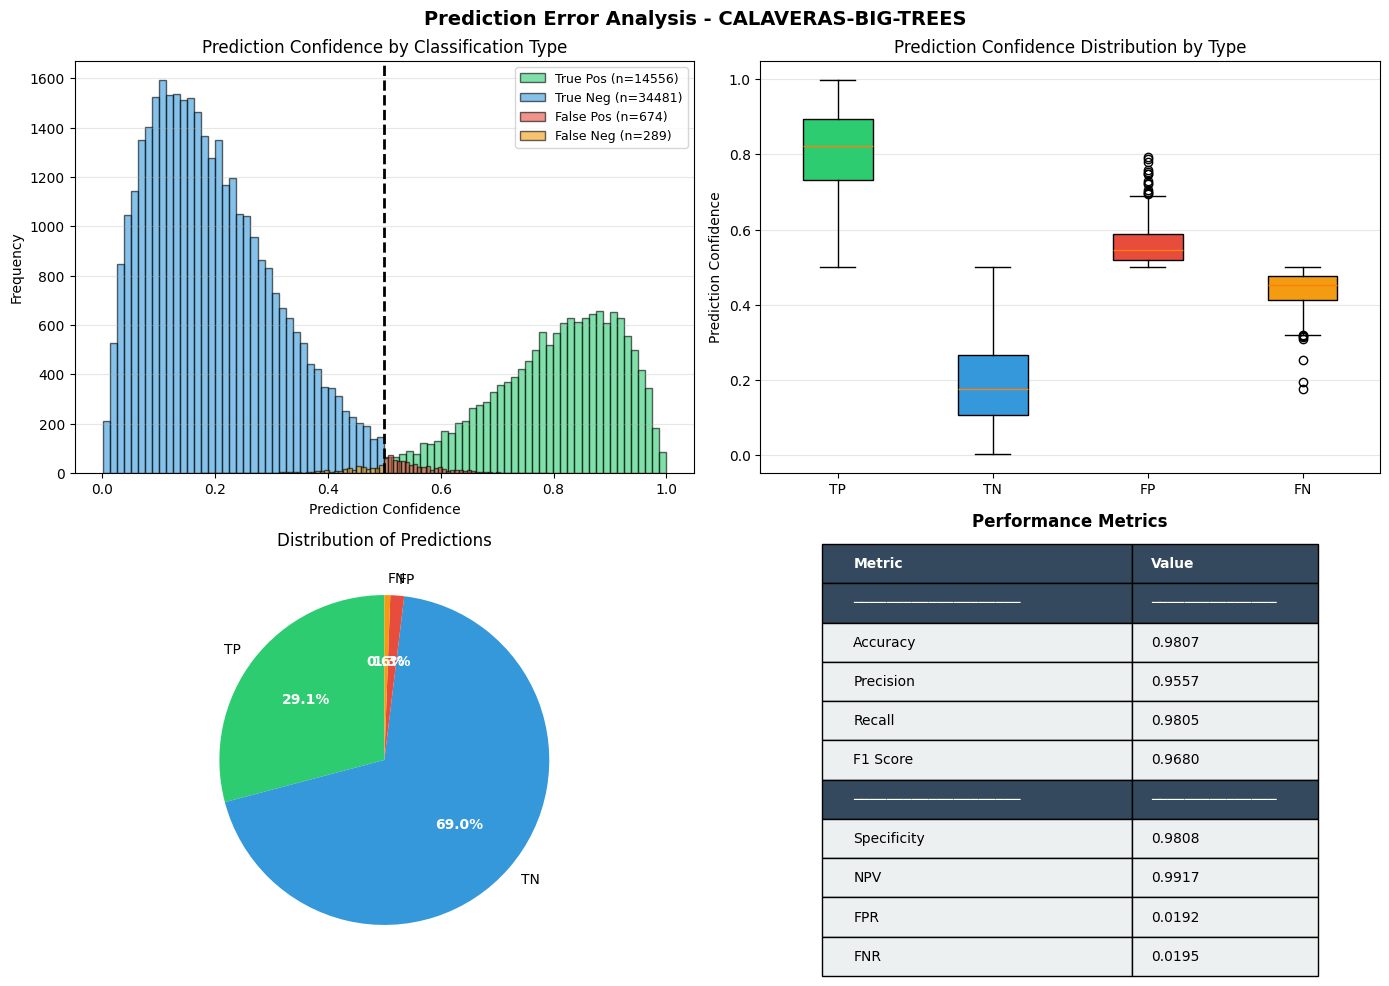

In [8]:
# Analyze prediction errors and patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Prediction Error Analysis - {test_site.upper()}", fontsize=14, fontweight='bold')

# Precompute prediction classes
tp_preds = predictions[(binary_preds == 1) & (labels == 1)]
tn_preds = predictions[(binary_preds == 0) & (labels == 0)]
fp_preds = predictions[(binary_preds == 1) & (labels == 0)]
fn_preds = predictions[(binary_preds == 0) & (labels == 1)]

# Plot 1: Distribution by classification type
ax = axes[0, 0]
ax.hist(tp_preds, bins=40, alpha=0.6, label=f'True Pos (n={len(tp_preds)})', color='#2ecc71', edgecolor='black')
ax.hist(tn_preds, bins=40, alpha=0.6, label=f'True Neg (n={len(tn_preds)})', color='#3498db', edgecolor='black')
ax.hist(fp_preds, bins=40, alpha=0.6, label=f'False Pos (n={len(fp_preds)})', color='#e74c3c', edgecolor='black')
ax.hist(fn_preds, bins=40, alpha=0.6, label=f'False Neg (n={len(fn_preds)})', color='#f39c12', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Confidence by Classification Type')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Box plot of predictions by class
ax = axes[0, 1]
data_to_plot = [tp_preds, tn_preds, fp_preds, fn_preds]
bp = ax.boxplot(data_to_plot, labels=['TP', 'TN', 'FP', 'FN'], patch_artist=True)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Prediction Confidence')
ax.set_title('Prediction Confidence Distribution by Type')
ax.grid(axis='y', alpha=0.3)

# Plot 3: Classification metrics breakdown
ax = axes[1, 0]
categories = ['TP', 'TN', 'FP', 'FN']
counts = [tp, tn, fp, fn]
colors_pie = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
wedges, texts, autotexts = ax.pie(counts, labels=categories, colors=colors_pie, autopct='%1.1f%%',
                                    startangle=90, textprops={'fontsize': 10})
ax.set_title('Distribution of Predictions')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Plot 4: Metrics comparison table
ax = axes[1, 1]
ax.axis('off')

specificity = metrics['specificity']
npv = metrics['npv']
fpr = metrics['fpr']
fnr = metrics['fnr']

metrics_data = [
    ['Metric', 'Value'],
    ['─' * 20, '─' * 15],
    ['Accuracy', f'{metrics['accuracy']:.4f}'],
    ['Precision', f'{metrics['precision']:.4f}'],
    ['Recall', f'{metrics['recall']:.4f}'],
    ['F1 Score', f'{metrics['f1']:.4f}'],
    ['─' * 20, '─' * 15],
    ['Specificity', f'{metrics['specificity']:.4f}'],
    ['NPV', f'{metrics['npv']:.4f}'],
    ['FPR', f'{metrics['fpr']:.4f}'],
    ['FNR', f'{metrics['fnr']:.4f}'],
]

metrics_data = metrics_data

table = ax.table(cellText=metrics_data, cellLoc='left', loc='center',
                colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(metrics_data)):
    if i in [0, 1, 6]:  # Header and separator rows
        table[(i, 0)].set_facecolor('#34495e')
        table[(i, 1)].set_facecolor('#34495e')
        table[(i, 0)].set_text_props(weight='bold', color='white')
        table[(i, 1)].set_text_props(weight='bold', color='white')
    else:
        table[(i, 0)].set_facecolor('#ecf0f1')
        table[(i, 1)].set_facecolor('#ecf0f1')

ax.set_title('Performance Metrics', pad=20, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

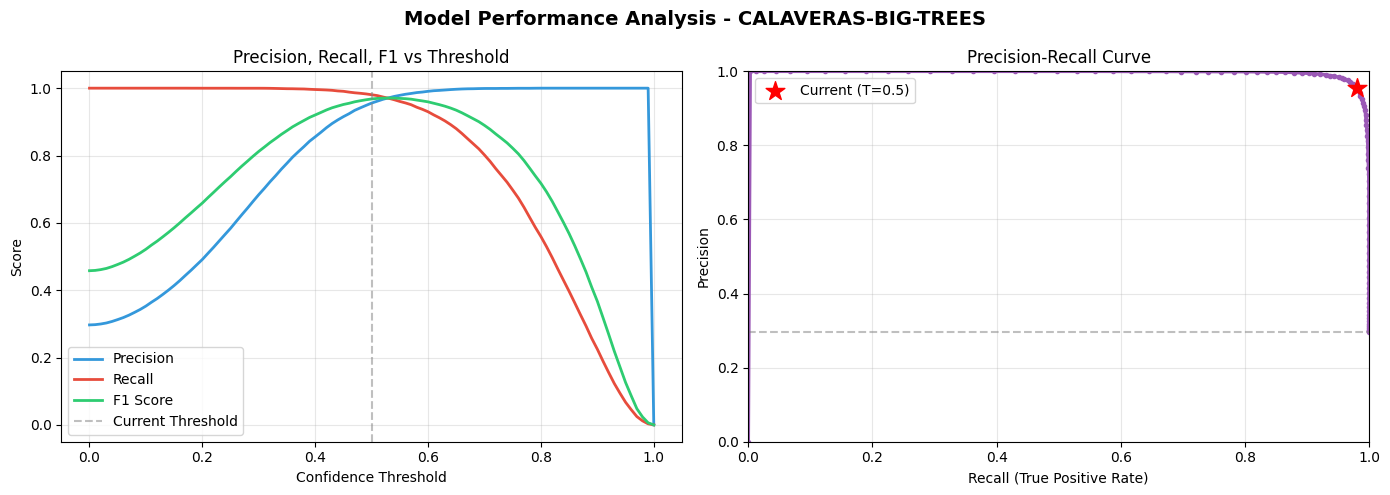

In [9]:
# Visualize precision-recall curve and ROC-like analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Model Performance Analysis - {test_site.upper()}", fontsize=14, fontweight='bold')

# Plot 1: Precision, Recall, F1 vs Threshold
ax = axes[0]
thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []
f1s = []

for thresh in thresholds:
    bin_pred = (predictions > thresh).astype(int)
    tp_t = np.sum((bin_pred == 1) & (labels == 1))
    fp_t = np.sum((bin_pred == 1) & (labels == 0))
    fn_t = np.sum((bin_pred == 0) & (labels == 1))
    
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

ax.plot(thresholds, precisions, linewidth=2, label='Precision', color='#3498db')
ax.plot(thresholds, recalls, linewidth=2, label='Recall', color='#e74c3c')
ax.plot(thresholds, f1s, linewidth=2, label='F1 Score', color='#2ecc71')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Current Threshold')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1 vs Threshold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision-Recall curve
ax = axes[1]
ax.plot(recalls, precisions, linewidth=2.5, color='#9b59b6', marker='o', markersize=3)
ax.scatter([metrics["recall"]], [metrics["precision"]], s=200, c='red', marker='*', zorder=5, label=f'Current (T=0.5)')
ax.set_xlabel('Recall (True Positive Rate)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=np.mean(labels), color='gray', linestyle='--', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.show()

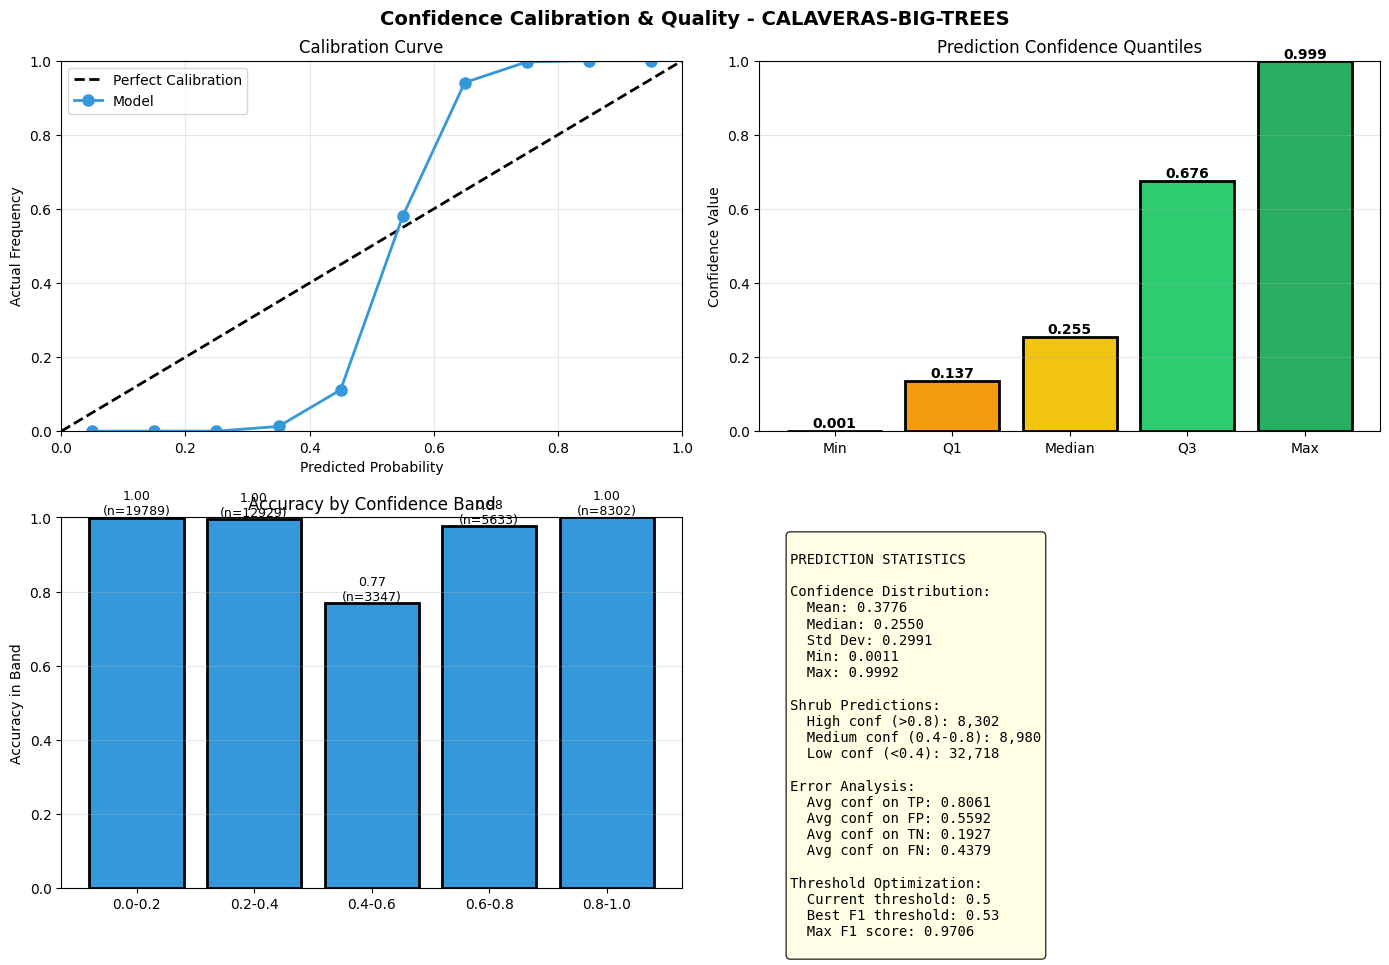

In [10]:
# Calibration and confidence analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Confidence Calibration & Quality - {test_site.upper()}", fontsize=14, fontweight='bold')

# Plot 1: Calibration curve - actual vs predicted frequency
ax = axes[0, 0]
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
actual_freq = []
pred_freq = []

for i in range(len(bins) - 1):
    mask = (predictions >= bins[i]) & (predictions < bins[i+1])
    if np.sum(mask) > 0:
        actual_freq.append(np.mean(labels[mask]))
        pred_freq.append(bin_centers[i])

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.plot(pred_freq, actual_freq, 'o-', linewidth=2, markersize=8, color='#3498db', label='Model')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Actual Frequency')
ax.set_title('Calibration Curve')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Confidence distribution statistics by quantile
ax = axes[0, 1]
quantiles = [0, 0.25, 0.5, 0.75, 1.0]
quantile_values = np.quantile(predictions, quantiles)
q_labels = ['Min', 'Q1', 'Median', 'Q3', 'Max']
colors_quant = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(q_labels, quantile_values, color=colors_quant, edgecolor='black', linewidth=2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Confidence Value')
ax.set_title('Prediction Confidence Quantiles')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 3: Accuracy by confidence bands
ax = axes[1, 0]
conf_bands = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
band_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
band_accs = []
band_counts = []

for low, high in conf_bands:
    mask = (predictions >= low) & (predictions < high)
    if np.sum(mask) > 0:
        band_accs.append(np.mean(binary_preds[mask] == labels[mask]))
        band_counts.append(np.sum(mask))
    else:
        band_accs.append(0)
        band_counts.append(0)

bars = ax.bar(band_labels, band_accs, color='#3498db', edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy in Band')
ax.set_title('Accuracy by Confidence Band')
ax.set_ylim([0, 1])
for i, (bar, count) in enumerate(zip(bars, band_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 4: Summary statistics
ax = axes[1, 1]
ax.axis('off')

stats_text = f"""
PREDICTION STATISTICS

Confidence Distribution:
  Mean: {np.mean(predictions):.4f}
  Median: {np.median(predictions):.4f}
  Std Dev: {np.std(predictions):.4f}
  Min: {np.min(predictions):.4f}
  Max: {np.max(predictions):.4f}

Shrub Predictions:
  High conf (>0.8): {np.sum(predictions > 0.8):,}
  Medium conf (0.4-0.8): {np.sum((predictions >= 0.4) & (predictions <= 0.8)):,}
  Low conf (<0.4): {np.sum(predictions < 0.4):,}

Error Analysis:
  Avg conf on TP: {np.mean(predictions[(binary_preds == 1) & (labels == 1)]):.4f}
  Avg conf on FP: {np.mean(predictions[(binary_preds == 1) & (labels == 0)]):.4f}
  Avg conf on TN: {np.mean(predictions[(binary_preds == 0) & (labels == 0)]):.4f}
  Avg conf on FN: {np.mean(predictions[(binary_preds == 0) & (labels == 1)]):.4f}

Threshold Optimization:
  Current threshold: 0.5
  Best F1 threshold: {thresholds[np.argmax(f1s)]:.2f}
  Max F1 score: {np.max(f1s):.4f}
"""

ax.text(0.05, 0.95, stats_text, fontsize=10, verticalalignment='top',
       family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

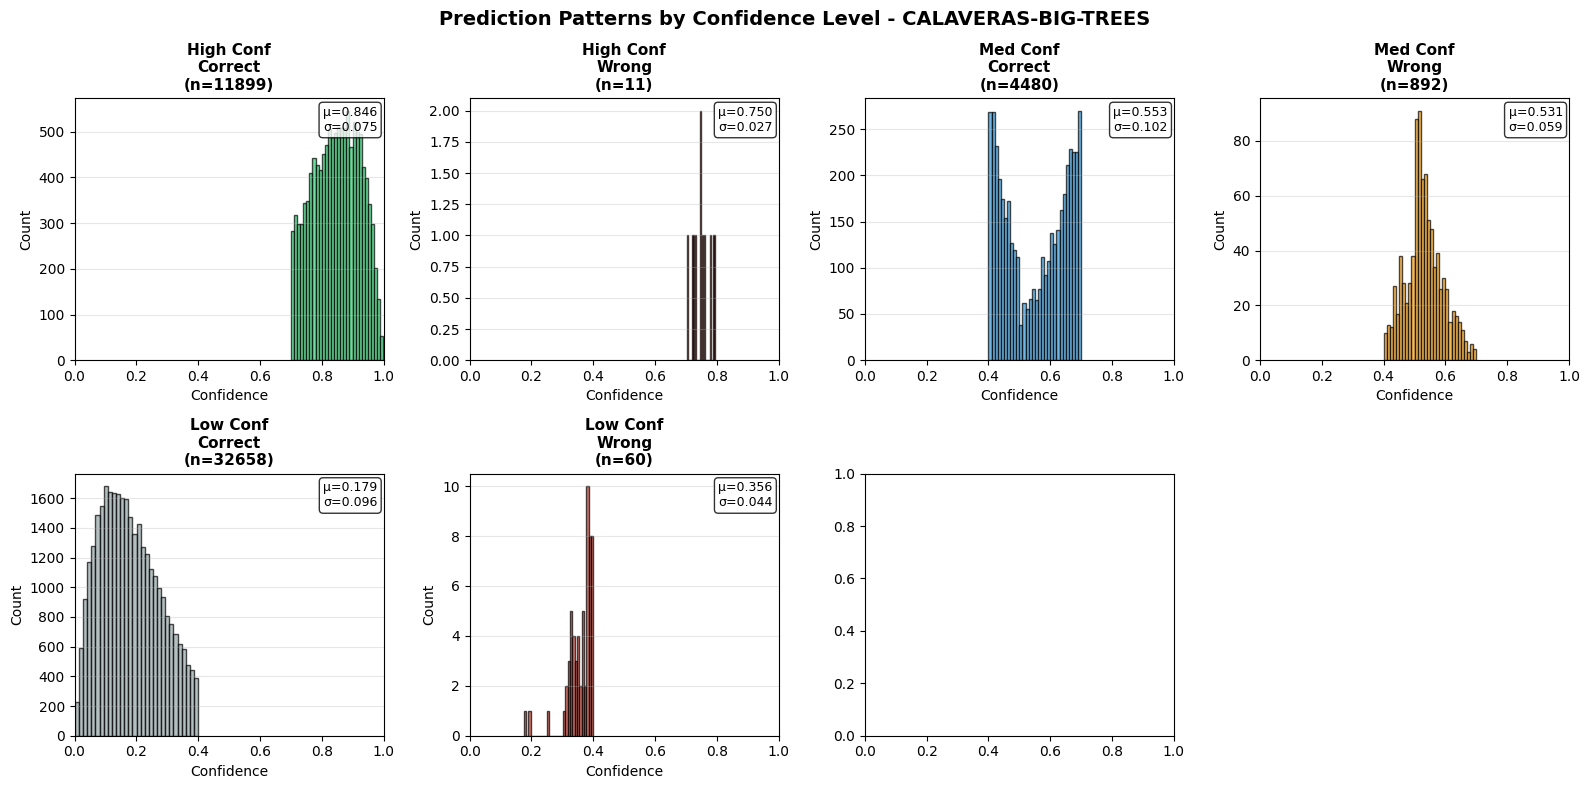

In [11]:
# Visualize prediction patterns: high confidence vs uncertain regions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"Prediction Patterns by Confidence Level - {test_site.upper()}", fontsize=14, fontweight='bold')

# Categorize predictions by confidence and correctness
high_conf_correct = predictions[(predictions > 0.7) & (binary_preds == labels)]
high_conf_wrong = predictions[(predictions > 0.7) & (binary_preds != labels)]
med_conf_correct = predictions[((predictions >= 0.4) & (predictions <= 0.7)) & (binary_preds == labels)]
med_conf_wrong = predictions[((predictions >= 0.4) & (predictions <= 0.7)) & (binary_preds != labels)]
low_conf_correct = predictions[(predictions < 0.4) & (binary_preds == labels)]
low_conf_wrong = predictions[(predictions < 0.4) & (binary_preds != labels)]

conf_groups = [
    ('High Conf\nCorrect', high_conf_correct, '#2ecc71'),
    ('High Conf\nWrong', high_conf_wrong, '#e74c3c'),
    ('Med Conf\nCorrect', med_conf_correct, '#3498db'),
    ('Med Conf\nWrong', med_conf_wrong, '#f39c12'),
    ('Low Conf\nCorrect', low_conf_correct, '#95a5a6'),
    ('Low Conf\nWrong', low_conf_wrong, '#c0392b'),
]

for idx, (title, data, color) in enumerate(conf_groups):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    if len(data) > 0:
        ax.hist(data, bins=30, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(f'{title}\n(n={len(data)})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Count')
        ax.set_xlim([0, 1])
        stats_str = f'μ={np.mean(data):.3f}\nσ={np.std(data):.3f}'
        ax.text(0.98, 0.97, stats_str, transform=ax.transAxes, 
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{title}\n(n=0)')
    
    ax.grid(axis='y', alpha=0.3)

# Hide last unused subplot
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

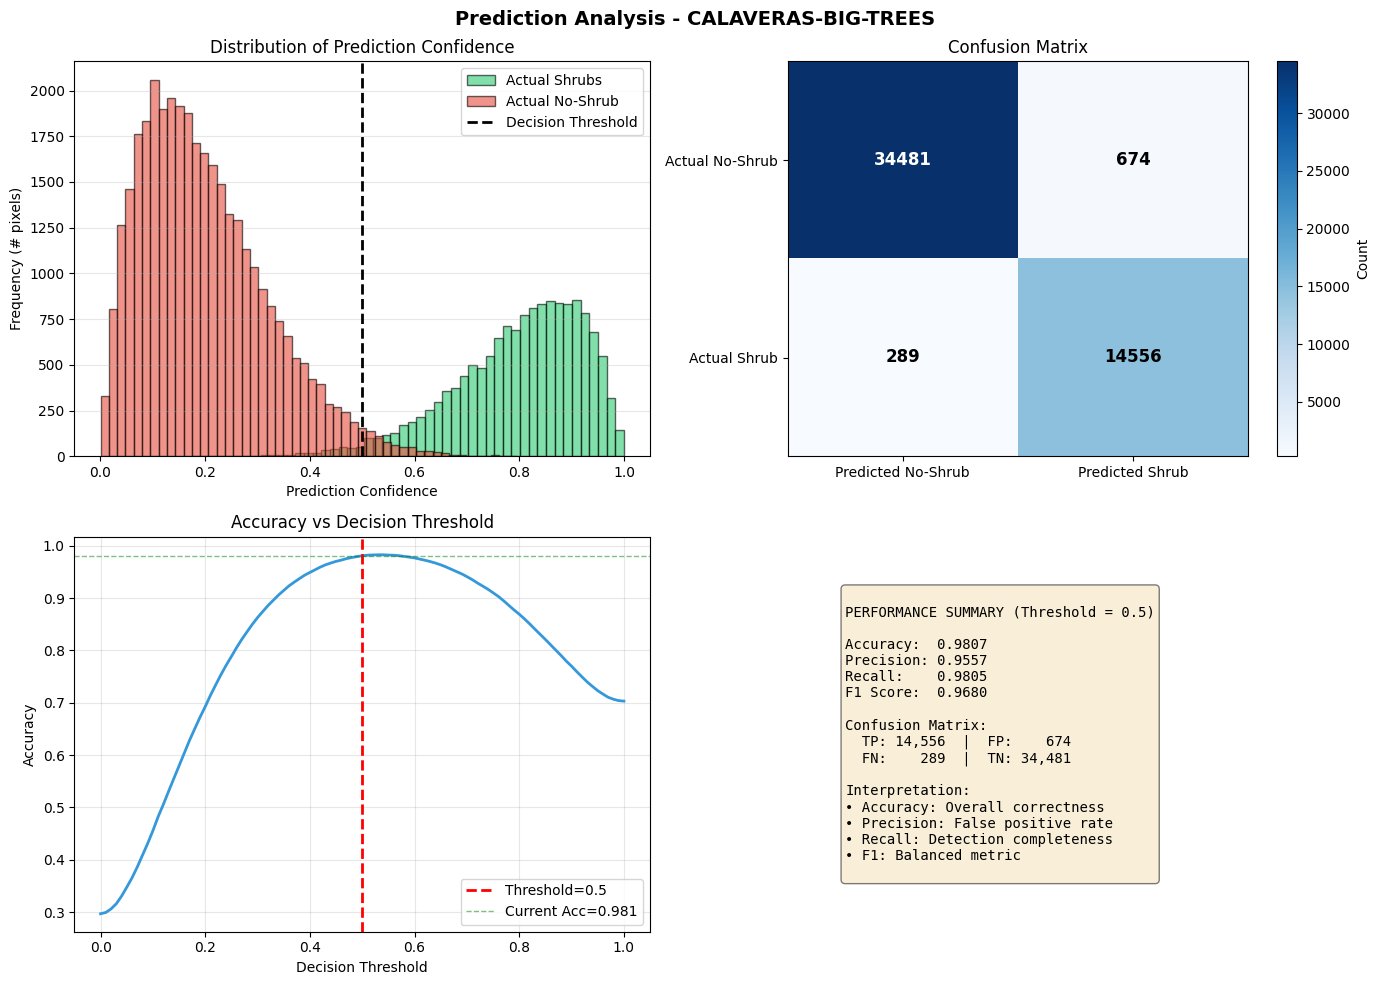

In [12]:
# Visualize prediction distributions and accuracy
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Prediction Analysis - {test_site.upper()}", fontsize=14, fontweight='bold')

# Plot 1: Histogram of predictions for shrub vs no-shrub pixels
ax = axes[0, 0]
shrub_preds = predictions[labels == 1]
no_shrub_preds = predictions[labels == 0]
ax.hist(shrub_preds, bins=50, alpha=0.6, label='Actual Shrubs', color='#2ecc71', edgecolor='black')
ax.hist(no_shrub_preds, bins=50, alpha=0.6, label='Actual No-Shrub', color='#e74c3c', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Frequency (# pixels)')
ax.set_title('Distribution of Prediction Confidence')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Confusion matrix heatmap
ax = axes[0, 1]
confusion = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(confusion, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No-Shrub', 'Predicted Shrub'])
ax.set_yticklabels(['Actual No-Shrub', 'Actual Shrub'])
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, confusion[i, j], ha="center", va="center", 
                      color="white" if confusion[i, j] > confusion.max() / 2 else "black",
                      fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Count')

# Plot 3: Accuracy vs Threshold
ax = axes[1, 0]
thresholds = np.linspace(0, 1, 101)
accuracies = []
for thresh in thresholds:
    bin_pred = (predictions > thresh).astype(int)
    acc = np.mean(bin_pred == labels)
    accuracies.append(acc)
ax.plot(thresholds, accuracies, linewidth=2, color='#3498db')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
ax.axhline(y=metrics["accuracy"], color='green', linestyle='--', linewidth=1, alpha=0.5, label=f'Current Acc={metrics["accuracy"]:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Decision Threshold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Metrics summary
ax = axes[1, 1]
ax.axis('off')
metrics_text = f"""
PERFORMANCE SUMMARY (Threshold = 0.5)

Accuracy:  {metrics["accuracy"]:.4f}
Precision: {metrics["precision"]:.4f}
Recall:    {metrics["recall"]:.4f}
F1 Score:  {metrics["f1"]:.4f}

Confusion Matrix:
  TP: {metrics["tp"]:6,}  |  FP: {metrics["fp"]:6,}
  FN: {metrics["fn"]:6,}  |  TN: {metrics["tn"]:6,}

Interpretation:
• Accuracy: Overall correctness
• Precision: False positive rate
• Recall: Detection completeness
• F1: Balanced metric
"""
ax.text(0.1, 0.5, metrics_text, fontsize=10, verticalalignment='center',
       family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()